# What Does an ER Visit Really Cost?

**Data:** Medical Expenditure Panel Survey (MEPS) 2023, from AHRQ — actual amounts *paid* per ER visit, not hospital sticker prices.

**Research questions**

1. What does an ER visit cost on average, and how much does it vary by condition?
2. Which conditions send people to the ER most often — and which are most expensive?
3. How do costs differ by insurance coverage, age group, and region?
4. How big is the gap between what hospitals *charge* and what actually gets *paid*?

**How the four data files fit together:**

```
 ER Visits (h248e)        Condition–Event Link (h248i)      Conditions (h249)
 one row per visit   ──►  EVNTIDX ↔ CONDIDX bridge     ──►  one row per condition
        │                                                    (CCSR category)
        └──► Person file (h251): demographics & insurance, joined on DUPERSID
```

> Run `python scripts/download_data.py` from the project root first to fetch the data.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# locate the project root: start from this notebook's location (VSCode
# exposes it as __vsc_ipynb_file__), else the working directory, and walk up
start = Path(globals().get("__vsc_ipynb_file__", Path.cwd())).parent \
        if "__vsc_ipynb_file__" in globals() else Path.cwd()
ROOT = start
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "data").exists():
    raise FileNotFoundError(
        "Couldn't find the project's data/ folder — in VSCode use "
        "File > Open Folder on er-cost-analysis, then re-run.")
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"

BLUE, AQUA = "#2a78d6", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "figure.dpi": 100,
})

def style_ax(ax, title):
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", color=INK, pad=12)
    ax.grid(axis="y", visible=False)

def save_fig(fig, name):
    fig.savefig(FIGURES / name, dpi=200, bbox_inches="tight")
    print(f"saved reports/figures/{name}")

## 1. Load the data

MEPS ships Stata (`.dta`) files. `pandas.read_stata` reads them directly and keeps
the *value labels* — so insurance shows up as `"1 ANY PRIVATE"` instead of a bare `1`.

A few MEPS files have duplicate labels that make pandas raise an error, so we
try with labels first and fall back to raw codes if needed.

In [2]:
def load_meps(stem):
    """Load a MEPS .dta file by name stem, with value labels when possible."""
    matches = [p for p in RAW.glob("*.dta") if p.stem.lower() == stem]
    if not matches:
        raise FileNotFoundError(
            f"{stem}.dta not found in data/raw — run: python scripts/download_data.py")
    try:
        df = pd.read_stata(matches[0])
    except ValueError:  # a few MEPS files have duplicate value labels
        df = pd.read_stata(matches[0], convert_categoricals=False)
    df.columns = df.columns.str.upper()
    return df

er   = load_meps("h248e")     # ER visits
cond = load_meps("h249")      # medical conditions
clnk = load_meps("h248if1")   # condition-event link
fyc  = load_meps("h251")      # person-level demographics & insurance

for name, df in [("ER visits", er), ("conditions", cond), ("link", clnk), ("persons", fyc)]:
    print(f"{name:<12} {df.shape[0]:>7,} rows x {df.shape[1]:>4} cols")

ER visits      4,241 rows x   53 cols
conditions    63,656 rows x   29 cols
link         281,158 rows x    6 cols
persons       18,919 rows x 1374 cols


## 2. First look at the money columns

Key ER-visit columns (the `23` means calendar year 2023, `X` means imputed/edited):

| Column | Meaning |
|---|---|
| `ERXP23X` | total **paid** for the visit, all payers combined |
| `ERTC23X` | total **charged** by the hospital (the sticker price) |
| `PERWT23F` | survey weight = how many Americans this person represents |

Negative values are MEPS codes for "missing/inapplicable", so we check for them
before averaging anything.

In [3]:
print(er[["ERXP23X", "ERTC23X", "PERWT23F"]].describe().round(1))
print(f"\nvisits with negative (missing) payment: {(er['ERXP23X'] < 0).sum()}")
print(f"visits with $0 payment: {(er['ERXP23X'] == 0).sum()}")

        ERXP23X   ERTC23X  PERWT23F
count    4241.0    4241.0    4241.0
mean     1227.9    5398.6   15924.6
std      4199.5   11928.8   11400.9
min         0.0       0.0       0.0
25%       206.7    1066.0    8366.0
50%       578.2    3008.8   13293.2
75%      1272.0    6378.6   20038.4
max    195314.5  425391.7  125182.0

visits with negative (missing) payment: 0
visits with $0 payment: 367


## 3. Build one analysis table

The merge chain: **visits → link table → conditions**, then join person
demographics. One visit can be linked to several conditions — that's fine, it
just means a visit counts once under each condition it involves.

Conditions come as CCSR codes (`"CIR007"`). The reference file downloaded by the
script maps codes to names ("Essential hypertension"); if it's missing we fall
back to broad body-system labels from the 3-letter prefix.

In [4]:
visits = (
    er.loc[er["ERXP23X"] >= 0,
           ["DUPERSID", "EVNTIDX", "ERXP23X", "ERTC23X", "PERWT23F"]]
      .copy()
)
links = clnk[["EVNTIDX", "CONDIDX"]].drop_duplicates()
conditions = cond[["CONDIDX", "ICD10CDX", "CCSR1X"]].copy()

want = ["DUPERSID", "AGELAST", "SEX", "REGION23", "INSCOV23", "RACETHX", "POVCAT23"]
persons = fyc[[c for c in want if c in fyc.columns]].copy()

visit_cond = (
    visits
    .merge(links, on="EVNTIDX", how="inner")
    .merge(conditions, on="CONDIDX", how="inner")
    .merge(persons, on="DUPERSID", how="left")
)
print(f"{len(visits):,} ER visits -> {len(visit_cond):,} visit-condition rows")
visit_cond.head(3)

4,241 ER visits -> 4,294 visit-condition rows


,DUPERSID,EVNTIDX,ERXP23X,ERTC23X,PERWT23F,CONDIDX,ICD10CDX,CCSR1X,AGELAST,SEX,REGION23,INSCOV23,RACETHX,POVCAT23
0,2790032106,2790032106001001,449.11,8717.00,12162.846840,2790032106002,-15,DIG000,9,1 MALE,3 SOUTH,2 PUBLIC ONLY,1 HISPANIC,1 POOR/NEGATIVE
1,2790032106,2790032106001001,449.11,8717.00,12162.846840,2790032106004,A08,DIG001,9,1 MALE,3 SOUTH,2 PUBLIC ONLY,1 HISPANIC,1 POOR/NEGATIVE
2,2790037101,2790037101007201,633.36,4664.15,9676.522242,2790037101019,U07,INF012,77,2 FEMALE,1 NORTHEAST,1 ANY PRIVATE,2 NON-HISPANIC WHITE ONLY,5 HIGH INCOME


In [5]:
def load_ccsr_labels(path):
    """Find the CCSR code -> description mapping in the reference workbook."""
    if not path.exists():
        return {}
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        for header_row in range(3):
            df = xl.parse(sheet, header=header_row)
            cols = [c for c in df.columns if isinstance(c, str)]
            code_col = next((c for c in cols if "ccsr" in c.lower()
                             and "category" in c.lower()
                             and "description" not in c.lower()), None)
            desc_col = next((c for c in cols if "description" in c.lower()), None)
            if code_col and desc_col:
                pairs = df[[code_col, desc_col]].dropna()
                mapping = dict(zip(pairs[code_col].astype(str).str.strip(),
                                   pairs[desc_col].astype(str).str.strip()))
                if len(mapping) > 100:
                    return mapping
    return {}

# fallback labels from the CCSR code's 3-letter body-system prefix
BODY_SYSTEM = {
    "BLD": "Blood disorders", "CIR": "Circulatory", "DIG": "Digestive",
    "EAR": "Ear", "END": "Endocrine/metabolic", "EXT": "External causes",
    "EYE": "Eye", "FAC": "Health status factors", "GEN": "Genitourinary",
    "INF": "Infectious diseases", "INJ": "Injury & poisoning",
    "MAL": "Congenital malformations", "MBD": "Mental/behavioral",
    "MUS": "Musculoskeletal", "NEO": "Neoplasms", "NVS": "Nervous system",
    "PNL": "Perinatal", "PRG": "Pregnancy/childbirth", "RSP": "Respiratory",
    "SKN": "Skin", "SYM": "Symptoms & signs",
}

ccsr_labels = load_ccsr_labels(RAW / "ccsr_reference.xlsx")
print(f"CCSR reference labels loaded: {len(ccsr_labels)}")

ccsr = visit_cond["CCSR1X"].astype(str).str.strip()
visit_cond["condition"] = (
    ccsr.map(ccsr_labels)
        .fillna(ccsr.str[:3].map(BODY_SYSTEM))
        .fillna("Unclassified")
)
visit_cond["body_system"] = ccsr.str[:3].map(BODY_SYSTEM).fillna("Unclassified")

PROCESSED.mkdir(parents=True, exist_ok=True)
visit_cond.to_csv(PROCESSED / "er_visit_conditions_2023.csv", index=False)
visit_cond[["ERXP23X", "condition", "body_system"]].head()

CCSR reference labels loaded: 558


,ERXP23X,condition,body_system
0,449.11,Digestive,Digestive
1,449.11,Intestinal infection,Digestive
2,633.36,Coronavirus disease – 2019 (COVID-19),Infectious diseases
3,1009.10,Chronic obstructive pulmonary disease and bron...,Respiratory
4,636.33,Coronary atherosclerosis and other heart disease,Circulatory


## 4. What does an ER visit cost overall?

Two things matter for every number below:

- **Weighted:** each visit is multiplied by its survey weight (`PERWT23F`) so
  the answer describes the whole U.S. population, not just the ~20k surveyed
  households.
- **Median vs mean:** medical costs are heavily skewed. A few catastrophic
  visits pull the mean far above what a *typical* visit costs. Report both.

In [6]:
def weighted_mean(values, weights):
    return np.average(values, weights=weights)

def weighted_median(values, weights):
    """The value below which half of the weighted population sits."""
    order = np.argsort(values)
    v, w = np.asarray(values)[order], np.asarray(weights)[order]
    return v[np.searchsorted(np.cumsum(w), 0.5 * w.sum())]

# visit-level table, so multi-condition visits count once
paid, wt = visits["ERXP23X"], visits["PERWT23F"]
print(f"weighted mean paid per ER visit:   ${weighted_mean(paid, wt):,.0f}")
print(f"weighted median paid per ER visit: ${weighted_median(paid, wt):,.0f}")
print(f"unweighted sample size:            {len(visits):,} visits")

weighted mean paid per ER visit:   $1,315
weighted median paid per ER visit: $591
unweighted sample size:            4,241 visits


saved reports/figures/01_cost_distribution.png


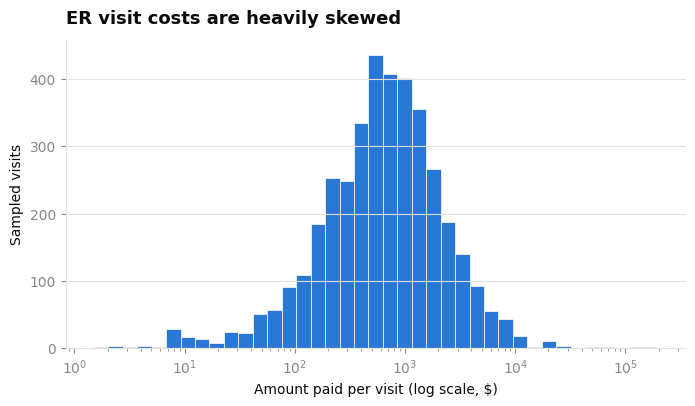

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
positive = visits.loc[visits["ERXP23X"] > 0, "ERXP23X"]
ax.hist(positive, bins=np.geomspace(positive.min(), positive.max(), 40),
        color=BLUE, edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_xlabel("Amount paid per visit (log scale, $)")
ax.set_ylabel("Sampled visits")
ax.grid(axis="x", visible=False)
ax.set_title("ER visit costs are heavily skewed", loc="left",
             fontsize=13, fontweight="bold", color=INK, pad=12)
save_fig(fig, "01_cost_distribution.png")
plt.show()

## 5. Cost by condition (the core question)

For each CCSR condition category we compute:

- `visits_sampled` — raw rows (used to filter out categories too small to trust)
- `visits_weighted` — estimated national number of visits
- `avg_paid` / `median_paid` — weighted cost per visit

Categories with fewer than **50 sampled visits** are dropped. Small samples
make averages jump around too much to rank.

In [8]:
MIN_SAMPLE = 50

by_condition = (
    visit_cond.groupby("condition")
    .apply(lambda g: pd.Series({
        "visits_sampled":  len(g),
        "visits_weighted": g["PERWT23F"].sum(),
        "avg_paid":        weighted_mean(g["ERXP23X"], g["PERWT23F"]),
        "median_paid":     weighted_median(g["ERXP23X"], g["PERWT23F"]),
    }), include_groups=False)
    .query("visits_sampled >= @MIN_SAMPLE")
    .sort_values("avg_paid", ascending=False)
)

print(f"{len(by_condition)} condition categories with >= {MIN_SAMPLE} sampled visits")
by_condition.head(10).round(0)

23 condition categories with >= 50 sampled visits


,visits_sampled,visits_weighted,avg_paid,median_paid
condition,,,,
Digestive,104.0,1603072.0,2182.0,675.0
Fluid and electrolyte disorders,82.0,1151823.0,1880.0,526.0
Unclassified,68.0,1125351.0,1842.0,849.0
Abdominal pain and other digestive/abdomen signs and symptoms,80.0,1319335.0,1713.0,950.0
Essential hypertension,129.0,1758145.0,1635.0,505.0
"Musculoskeletal pain, not low back pain",112.0,1856378.0,1593.0,537.0
Anxiety and fear-related disorders,64.0,1010881.0,1535.0,816.0
"Other unspecified injuries, subsequent encounter",204.0,3237464.0,1315.0,789.0
"Fracture of the upper limb, subsequent encounter",62.0,999101.0,1307.0,745.0


saved reports/figures/02_top_conditions_by_cost.png


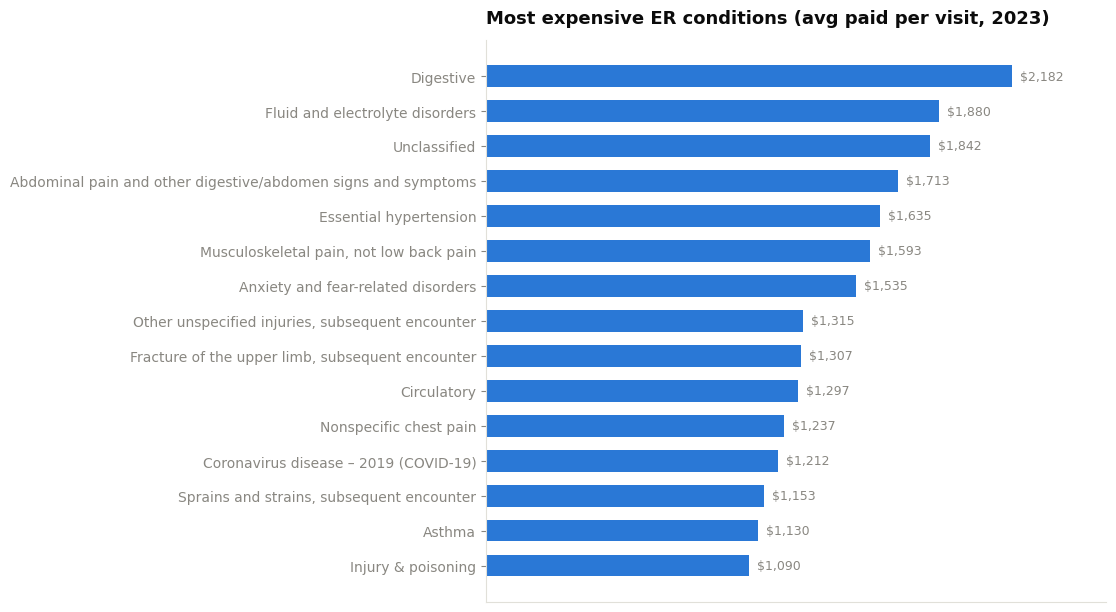

saved reports/figures/03_top_conditions_by_volume.png


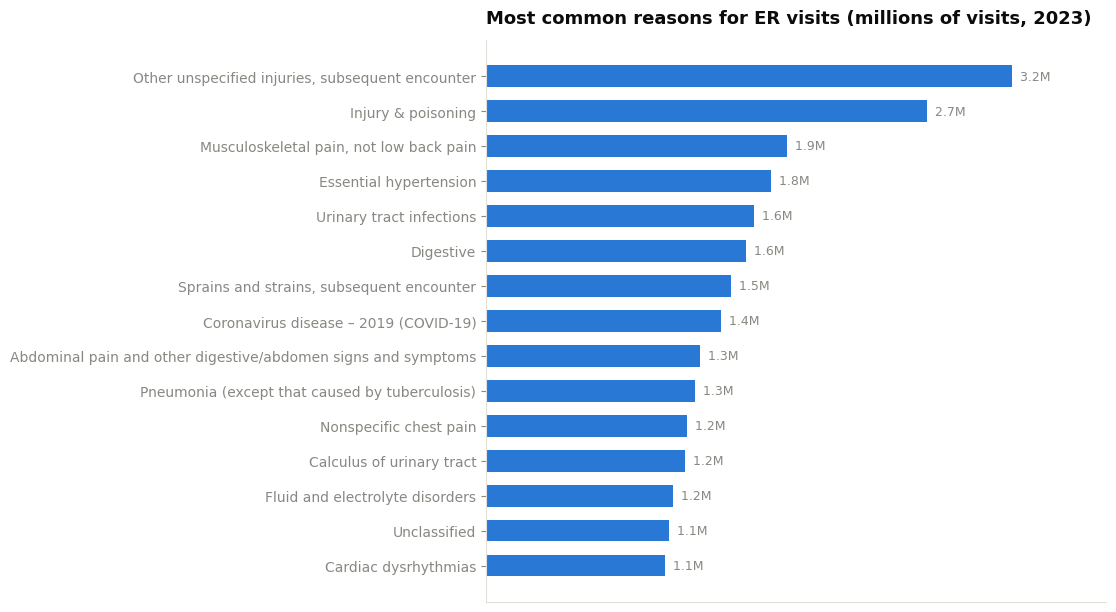

In [9]:
def hbar(series, title, fname, color=BLUE, fmt="${:,.0f}"):
    """Horizontal bar chart with direct value labels."""
    fig, ax = plt.subplots(figsize=(8, 0.42 * len(series) + 1))
    series = series.iloc[::-1]
    ax.barh(series.index, series.values, color=color, height=0.62)
    for i, v in enumerate(series.values):
        ax.text(v, i, "  " + fmt.format(v), va="center", fontsize=9, color=MUTED)
    ax.set_xlim(0, series.max() * 1.18)
    ax.xaxis.set_visible(False)
    style_ax(ax, title)
    save_fig(fig, fname)
    plt.show()

hbar(by_condition["avg_paid"].head(15),
     "Most expensive ER conditions (avg paid per visit, 2023)",
     "02_top_conditions_by_cost.png")

hbar(by_condition.sort_values("visits_weighted", ascending=False)["visits_weighted"].head(15) / 1e6,
     "Most common reasons for ER visits (millions of visits, 2023)",
     "03_top_conditions_by_volume.png", fmt="{:,.1f}M")

## 6. Breakdowns — who pays more?

One helper computes weighted cost stats for any grouping column; applied below
to insurance coverage, then age group and census region.

             visits_sampled  avg_paid  median_paid
INSCOV23                                          
Any Private          1617.0    1915.0        791.0
Uninsured              85.0    1364.0        590.0
Public Only          1925.0     725.0        478.0
saved reports/figures/04_cost_by_insurance.png


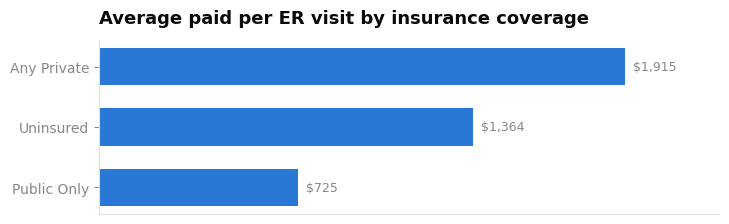

In [10]:
def breakdown(df, by):
    """Weighted cost stats per group, at the visit level (each visit once)."""
    sub = df.drop_duplicates("EVNTIDX").dropna(subset=[by])
    # drop MEPS missing-data codes like "-1 INAPPLICABLE"
    sub = sub[~sub[by].astype(str).str.match(r"\s*-\d")]
    out = (
        sub.groupby(by, observed=True)
        .apply(lambda g: pd.Series({
            "visits_sampled": len(g),
            "avg_paid":    weighted_mean(g["ERXP23X"], g["PERWT23F"]),
            "median_paid": weighted_median(g["ERXP23X"], g["PERWT23F"]),
        }), include_groups=False)
        .query("visits_sampled >= 50")
    )
    # strip the leading code number from MEPS labels ("1 ANY PRIVATE" -> "Any Private")
    out.index = out.index.astype(str).str.replace(r"^\s*-?\d+\s+", "", regex=True).str.title()
    return out.sort_values("avg_paid", ascending=False)

ins = breakdown(visit_cond, "INSCOV23")
print(ins.round(0))
hbar(ins["avg_paid"], "Average paid per ER visit by insurance coverage",
     "04_cost_by_insurance.png")

Age and region use the same helper — the only new step is binning ages into
groups with `pd.cut`.

In [11]:
visit_cond["age_group"] = pd.cut(
    visit_cond["AGELAST"],
    bins=[0, 18, 40, 65, 120],
    labels=["0-17", "18-39", "40-64", "65+"],
    right=False,
)
display(breakdown(visit_cond, "age_group").round(0))
display(breakdown(visit_cond, "REGION23").round(0))

,visits_sampled,avg_paid,median_paid
age_group,,,
40-64,1138.0,1723.0,721.0
18-39,605.0,1659.0,612.0
0-17,448.0,1066.0,545.0
65+,1436.0,886.0,512.0


,visits_sampled,avg_paid,median_paid
REGION23,,,
South,1423.0,1485.0,584.0
West,738.0,1318.0,661.0
Midwest,801.0,1267.0,581.0
Northeast,570.0,1222.0,592.0


## 7. Sticker price vs. reality

Hospitals bill a "charge" (`ERTC23X`) that almost nobody actually pays; insurers
negotiate it down and the paid amount (`ERXP23X`) is what really changes hands.
This gap is one of the most striking — and most shareable — findings in
healthcare data.

average charged: $5,675
average paid:    $1,435
-> hospitals charge 4.0x what is actually paid
saved reports/figures/05_charge_vs_paid.png


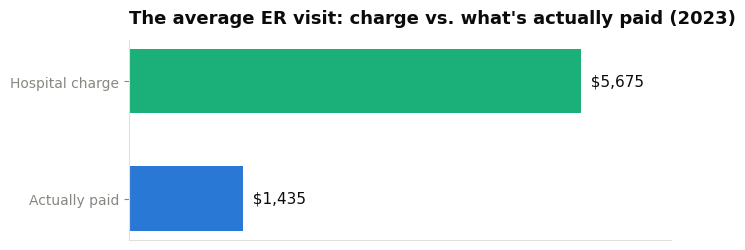

In [12]:
both = visits[(visits["ERTC23X"] > 0) & (visits["ERXP23X"] > 0)]
avg_charged = weighted_mean(both["ERTC23X"], both["PERWT23F"])
avg_paid    = weighted_mean(both["ERXP23X"], both["PERWT23F"])
print(f"average charged: ${avg_charged:,.0f}")
print(f"average paid:    ${avg_paid:,.0f}")
print(f"-> hospitals charge {avg_charged / avg_paid:.1f}x what is actually paid")

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(["Actually paid", "Hospital charge"], [avg_paid, avg_charged],
        color=[BLUE, AQUA], height=0.55)
for i, v in enumerate([avg_paid, avg_charged]):
    ax.text(v, i, f"  ${v:,.0f}", va="center", fontsize=11, color=INK)
ax.set_xlim(0, avg_charged * 1.2)
ax.xaxis.set_visible(False)
ax.grid(visible=False)
ax.set_title("The average ER visit: charge vs. what's actually paid (2023)",
             loc="left", fontsize=13, fontweight="bold", color=INK, pad=12)
save_fig(fig, "05_charge_vs_paid.png")
plt.show()

## 8. Key findings

The takeaways for the Squarespace write-up (all survey-weighted, MEPS 2023):

- The typical (median) ER visit cost **$591**, but the mean was **$1,315** — 2.2x
  higher, showing how a small share of catastrophic visits drives the average up.
- The most expensive condition category was **Digestive** at **$2,182** per visit;
  the least expensive was **chronic obstructive pulmonary disease (COPD)** at **$530**.
- The most frequent reason for a visit was **unspecified injuries (subsequent
  encounter)**, an estimated **3.2 million** visits nationally.
- **Privately** insured patients' visits cost **2.6x** more than **public-only** ones
  ($1,915 vs. $725 average paid).
- Hospitals charged **4.0x** what was actually paid ($5,675 charged vs. $1,435 paid).
- By age, **40–64-year-olds** had the priciest visits ($1,723 avg) vs. **$886** for
  the **65+** group; regionally the **South** was priciest ($1,485 avg).

*Charts are already exported to `reports/figures/` at 200 dpi, ready to drop
into Squarespace. Numbers above are reproduced automatically by the roll-up cell below.*

**Data:** Agency for Healthcare Research and Quality, Medical Expenditure Panel
Survey, 2023 Full Year Files. Estimates use MEPS survey weights; standard errors
that account for the complex survey design are out of scope here.

In [13]:
# Roll up every headline number into a ready-to-paste summary.
usd = "${:,.0f}".format

paid, wt = visits["ERXP23X"], visits["PERWT23F"]
mean_paid   = weighted_mean(paid, wt)
median_paid = weighted_median(paid, wt)
national_visits_m = wt.sum() / 1e6

most_expensive     = by_condition["avg_paid"].idxmax()
most_expensive_avg = by_condition["avg_paid"].max()
most_common        = by_condition["visits_weighted"].idxmax()
most_common_m      = by_condition["visits_weighted"].max() / 1e6
cheapest           = by_condition["avg_paid"].idxmin()
cheapest_avg       = by_condition["avg_paid"].min()

ins = breakdown(visit_cond, "INSCOV23")
ins_high, ins_low = ins.index[0], ins.index[-1]
ins_ratio = ins["avg_paid"].iloc[0] / ins["avg_paid"].iloc[-1]

both = visits[(visits["ERTC23X"] > 0) & (visits["ERXP23X"] > 0)]
avg_charged = weighted_mean(both["ERTC23X"], both["PERWT23F"])
avg_paid2   = weighted_mean(both["ERXP23X"], both["PERWT23F"])
markup = avg_charged / avg_paid2

lines = [
    "## Key findings",
    "",
    f"- MEPS 2023 represents an estimated **{national_visits_m:,.0f} million ER visits** "
    f"nationally (from {len(visits):,} sampled visits).",
    f"- The typical (median) ER visit cost **{usd(median_paid)}**, but the mean was "
    f"**{usd(mean_paid)}** — {mean_paid / median_paid:.1f}x higher, showing how a small "
    f"share of catastrophic visits drives spending.",
    f"- Most expensive condition category (min {MIN_SAMPLE} sampled visits): "
    f"**{most_expensive}** at **{usd(most_expensive_avg)}** per visit; the least "
    f"expensive was **{cheapest}** at **{usd(cheapest_avg)}**.",
    f"- Most common reason for a visit: **{most_common}**, an estimated "
    f"**{most_common_m:,.1f} million** visits.",
    f"- By coverage, **{ins_high}** visits averaged **{ins_ratio:.1f}x** the cost of "
    f"**{ins_low}** visits.",
    f"- Hospitals charged **{markup:.1f}x** what was actually paid on average "
    f"({usd(avg_charged)} charged vs. {usd(avg_paid2)} paid).",
]

if "age_group" in visit_cond.columns:
    age = breakdown(visit_cond, "age_group")
    lines.append(
        f"- The highest-cost age group was **{age.index[0]}** "
        f"({usd(age['avg_paid'].iloc[0])} avg per visit) vs. "
        f"**{usd(age['avg_paid'].iloc[-1])}** for the lowest (**{age.index[-1]}**).")
if "REGION23" in visit_cond.columns:
    reg = breakdown(visit_cond, "REGION23")
    lines.append(
        f"- Regionally, the **{reg.index[0]}** was priciest ({usd(reg['avg_paid'].iloc[0])} "
        f"avg) and the **{reg.index[-1]}** cheapest ({usd(reg['avg_paid'].iloc[-1])}).")

lines += [
    "",
    "*All figures are survey-weighted national estimates from MEPS 2023 (AHRQ). "
    "Point estimates only — complex-survey standard errors are out of scope.*",
]

summary = "\n".join(lines)
print(summary)

from IPython.display import Markdown
Markdown(summary)

## Key findings

- MEPS 2023 represents an estimated **68 million ER visits** nationally (from 4,241 sampled visits).
- The typical (median) ER visit cost **$591**, but the mean was **$1,315** — 2.2x higher, showing how a small share of catastrophic visits drives spending.
- Most expensive condition category (min 50 sampled visits): **Digestive** at **$2,182** per visit; the least expensive was **Chronic obstructive pulmonary disease and bronchiectasis** at **$530**.
- Most common reason for a visit: **Other unspecified injuries, subsequent encounter**, an estimated **3.2 million** visits.
- By coverage, **Any Private** visits averaged **2.6x** the cost of **Public Only** visits.
- Hospitals charged **4.0x** what was actually paid on average ($5,675 charged vs. $1,435 paid).
- The highest-cost age group was **40-64** ($1,723 avg per visit) vs. **$886** for the lowest (**65+**).
- Regionally, the **South** was priciest ($1,485 avg) and the **Northeast** cheapest ($1,222).

*All figures 

## Key findings

- MEPS 2023 represents an estimated **68 million ER visits** nationally (from 4,241 sampled visits).
- The typical (median) ER visit cost **$591**, but the mean was **$1,315** — 2.2x higher, showing how a small share of catastrophic visits drives spending.
- Most expensive condition category (min 50 sampled visits): **Digestive** at **$2,182** per visit; the least expensive was **Chronic obstructive pulmonary disease and bronchiectasis** at **$530**.
- Most common reason for a visit: **Other unspecified injuries, subsequent encounter**, an estimated **3.2 million** visits.
- By coverage, **Any Private** visits averaged **2.6x** the cost of **Public Only** visits.
- Hospitals charged **4.0x** what was actually paid on average ($5,675 charged vs. $1,435 paid).
- The highest-cost age group was **40-64** ($1,723 avg per visit) vs. **$886** for the lowest (**65+**).
- Regionally, the **South** was priciest ($1,485 avg) and the **Northeast** cheapest ($1,222).

*All figures are survey-weighted national estimates from MEPS 2023 (AHRQ). Point estimates only — complex-survey standard errors are out of scope.*